In [16]:
import os
os.environ["H5NETCDF_READ_BACKEND"] = "pyfive"

import xscen as xs
import xarray as xr
from xscen import CONFIG
from matplotlib import pyplot as plt
import xclim as xc
import figanos.matplotlib as fg
from datetime import datetime
import cartopy.crs as ccrs
import copy
import numpy as np
import random
import glob
import sys
import pandas as pd
import seaborn as sns
import math


from matplotlib import gridspec
from datetime import datetime

from matplotlib.colors import LogNorm

xr.set_options(keep_attrs=True)
fg.utils.set_mpl_style('ouranos')
xs.load_config("paths_ESPO-R.yml",)
cat=xs.DataCatalog(CONFIG['catsim'])


fe={ 'lakes':{'scale':'110m', 'edgecolor':'black', 'facecolor':'none'},'coastline':{'scale':'50m'}}
map_proj = ccrs.RotatedPole(
            pole_longitude=83.0,
            pole_latitude=42.5,
        )
sftlf= cat.search(source='CRCM5-SN', variable='sftlf',id='CMIP6_CORDEX_MPI-ESM1-2-LR_r1i1p1f1_OURANOS_CRCM5-SN_historical_r1_NAM-12' ).to_dataset()
ids=[
    'CMIP6_CORDEX_MPI-ESM1-2-LR_r1i1p1f1_OURANOS_CRCM5-SN_ssp370_r1_NAM-12',
    'CMIP6_CORDEX_CanESM5_r1i1p2f1_OURANOS_CRCM5-SN_ssp370_r1_NAM-12',
    'CMIP6_CORDEX_NorESM2-MM_r1i1p1f1_OURANOS_CRCM5-SN_ssp370_r1_NAM-12',
                         ]

HDF5-DIAG: Error detected in HDF5 (1.14.2) MPI-process 0:
  #000: H5A.c line 679 in H5Aopen_by_name(): unable to synchronously open attribute
    major: Attribute
    minor: Can't open object
  #001: H5A.c line 641 in H5A__open_by_name_api_common(): unable to open attribute: '_QuantizeBitGroomNumberOfSignificantDigits'
    major: Attribute
    minor: Can't open object
  #002: H5A.c line 464 in H5A__open_common(): unable to open attribute: '_QuantizeBitGroomNumberOfSignificantDigits'
    major: Attribute
    minor: Can't open object
  #003: H5VLcallback.c line 1138 in H5VL_attr_open(): attribute open failed
    major: Virtual Object Layer
    minor: Can't open object
  #004: H5VLcallback.c line 1105 in H5VL__attr_open(): attribute open failed
    major: Virtual Object Layer
    minor: Can't open object
  #005: H5VLnative_attr.c line 169 in H5VL__native_attr_open(): can't open attribute
    major: Attribute
    minor: Can't open object
  #006: H5Aint.c line 638 in H5A__open_by_name(): un

# Health Checks

In [13]:
# print any health checks raised
for m in ['oldDQM', 'Scaling', 'tasmin', 'DQM']:

    print(m)
    for f in np.sort(glob.glob(f"{CONFIG[m]}/checks/NAM/*")):
        print(f.split("/")[-1])
        ds= xr.open_zarr(f)
        print(ds.attrs['warnings'])
        for var in ds.data_vars:
            if ds[var].values:
                if var == 'pr_very_large_precipitation_events':
                    f= glob.glob(f"{CONFIG[m]}/*/*/*/*/*/*/*/*/*/{ds.attrs['cat:driving_model']}/*/{ds.attrs['cat:experiment']}/*/*/pr/*")[0]
                    ds_adj=xr.open_zarr(f, decode_timedelta=False)
                    ma=ds_adj.pr.max(keep_attrs=True).values
                    mm=xc.core.units.convert_units_to(f"{ma} kg m-2 s-1", 'mm/day', context='hydro')
                    print('max pr', ma, 'kg m-2 s-1', mm, 'mm/day'  )
    
                    ds_adj['pr']=xc.core.units.convert_units_to(ds_adj['pr'], 'mm/day', context='hydro')
                    above= ds_adj.where((ds_adj.pr>1650).compute(), drop=True)
                    frac= above.count()/ds_adj.count()
                    print(' number above 1650 mm/d', above.pr.count().values, "fraction", frac.pr.values)
                if var == 'tasmin_temperature_extremely_low':
                    f= glob.glob(f"{CONFIG[m]}/*/*/*/*/*/*/*/*/*/{ds.attrs['cat:driving_model']}/*/{ds.attrs['cat:experiment']}/*/*/tasmin/*")[0]
                    ds_adj=xr.open_zarr(f, decode_timedelta=False)
                    mi=ds_adj.tasmin.min().values
                    mm=xc.core.units.convert_units_to(f"{mi} K", 'degC')
                    print('min tasmin', mi, 'K', mm, 'degC'  )
        print('')
    print('')
    print('')

# min tasmin also seen in raw sim.


oldDQM
CMIP6_CORDEX_CanESM5_r1i1p2f1_OURANOS_CRCM5-SN_ssp370_r1_NAM-12+CaSR+NAM_checks.zarr.zip
The following health checks failed:
  - 'tasmin' has suspicious values according to the following flags: ['temperature_extremely_low'].
  - 'pr' has suspicious values according to the following flags: ['very_large_precipitation_events'].
max pr 0.060667496 kg m-2 s-1 5241.671669483185 mm/day
 number above 1650 mm/d 198 fraction 1.2964872690407868e-08
min tasmin 197.07893 K -76.07106628417966 degC

CMIP6_CORDEX_MPI-ESM1-2-LR_r1i1p1f1_OURANOS_CRCM5-SN_ssp370_r1_NAM-12+CaSR+NAM_checks.zarr.zip
The following health checks failed:
  - 'tasmin' has suspicious values according to the following flags: ['temperature_extremely_low'].
  - 'pr' has suspicious values according to the following flags: ['very_large_precipitation_events'].
max pr 0.1368202 kg m-2 s-1 11821.265029907227 mm/day
 number above 1650 mm/d 304 fraction 1.990566312062622e-08
min tasmin 195.85826 K -77.29173889160154 degC

CMIP6_COR

oldDQM
CMIP6_CORDEX_CanESM5_r1i1p2f1_OURANOS_CRCM5-SN_ssp370_r1_NAM-12+CaSR+NAM_checks.zarr.zip
The following health checks failed:
  - 'tasmin' has suspicious values according to the following flags: ['temperature_extremely_low'].
  - 'pr' has suspicious values according to the following flags: ['very_large_precipitation_events'].


/lustre06/project/6046550/scenario/environnements/envs/xscen-0.14/lib/python3.12/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "description" not found.



CMIP6_CORDEX_MPI-ESM1-2-LR_r1i1p1f1_OURANOS_CRCM5-SN_ssp370_r1_NAM-12+CaSR+NAM_checks.zarr.zip
The following health checks failed:
  - 'tasmin' has suspicious values according to the following flags: ['temperature_extremely_low'].
  - 'pr' has suspicious values according to the following flags: ['very_large_precipitation_events'].

CMIP6_CORDEX_NorESM2-MM_r1i1p1f1_OURANOS_CRCM5-SN_ssp370_r1_NAM-12+CaSR+NAM_checks.zarr.zip
The following health checks failed:
  - 'tasmin' has suspicious values according to the following flags: ['temperature_extremely_low'].
  - 'pr' has suspicious values according to the following flags: ['very_large_precipitation_events'].





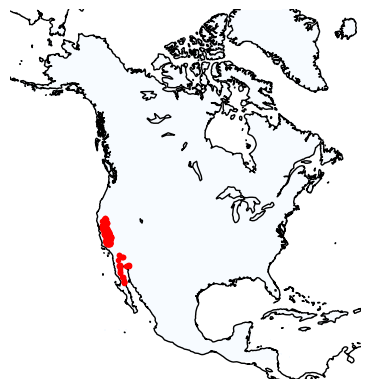

In [6]:
# print all exploding pr
fe={ 'lakes':{'scale':'110m', 'edgecolor':'black', 'facecolor':'none'},'coastline':{'scale':'50m'}}
map_proj = ccrs.RotatedPole(
            pole_longitude=83.0,
            pole_latitude=42.5,
        )


for m in ['oldDQM']:

    print(m)
    plot=True
    for f in np.sort(glob.glob(f"{CONFIG[m]}/checks/NAM/*")):
        print(f.split("/")[-1])
        ds= xr.open_zarr(f)
        print(ds.attrs['warnings'])
        for var in ds.data_vars:
            if ds[var].values:
                if var == 'pr_very_large_precipitation_events':
                    f= glob.glob(f"{CONFIG[m]}/*/*/*/*/*/*/*/*/*/{ds.attrs['cat:driving_model']}/*/{ds.attrs['cat:experiment']}/*/*/pr/*")[0]
                    ds_adj=xr.open_zarr(f, decode_timedelta=False)
                    ds_adj=xs.spatial.subset(ds_adj, method='bbox', lon_bnds= [ -179.95, -10 ],lat_bnds= [ 12.5, 83.4 ])

                    if plot:
                        ax=fg.gridmap(ds_adj.pr.isel(time=0), features=fe, projection=map_proj,
                                     plot_kw={'add_colorbar':False, "vmin":1000, "vmax":1001}, cmap='Blues')
                        plot=False

                    
                    ds_adj['pr']=xc.core.units.convert_units_to(ds_adj['pr'], 'mm/day', context='hydro')

                    # Create mask for extreme values
                    extreme_mask = ds_adj['pr'] > 1650
                    
                    # Get coordinates where condition is true
                    extreme_locs = ds_adj.where(extreme_mask.compute(), drop=True)
                    
                    # Convert to dataframe with all coordinates
                    df = extreme_locs['pr'].to_dataframe().reset_index()
                    
                    # Keep only rows with actual values (removes NaNs)
                    df = df.dropna(subset=['pr'])
                    print(len(df))
                    
                    for index, row in df.iterrows():
                        ax.plot(row['lon'], row['lat'], 'r.', transform=ccrs.PlateCarree())


        print('')
    print('')
    print('')
    plt.savefig(f"{CONFIG['figures']}/explodingpr.pdf",bbox_inches='tight')


# VALUE

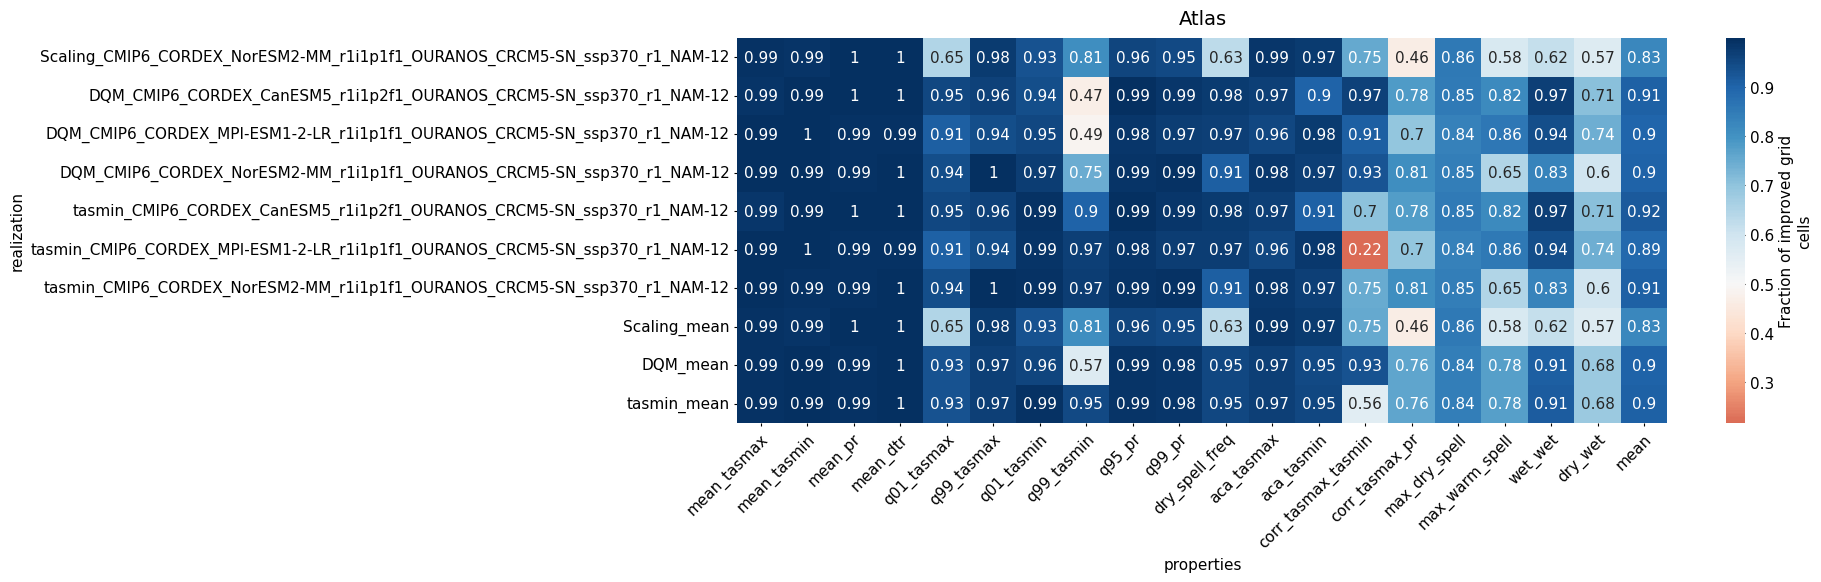

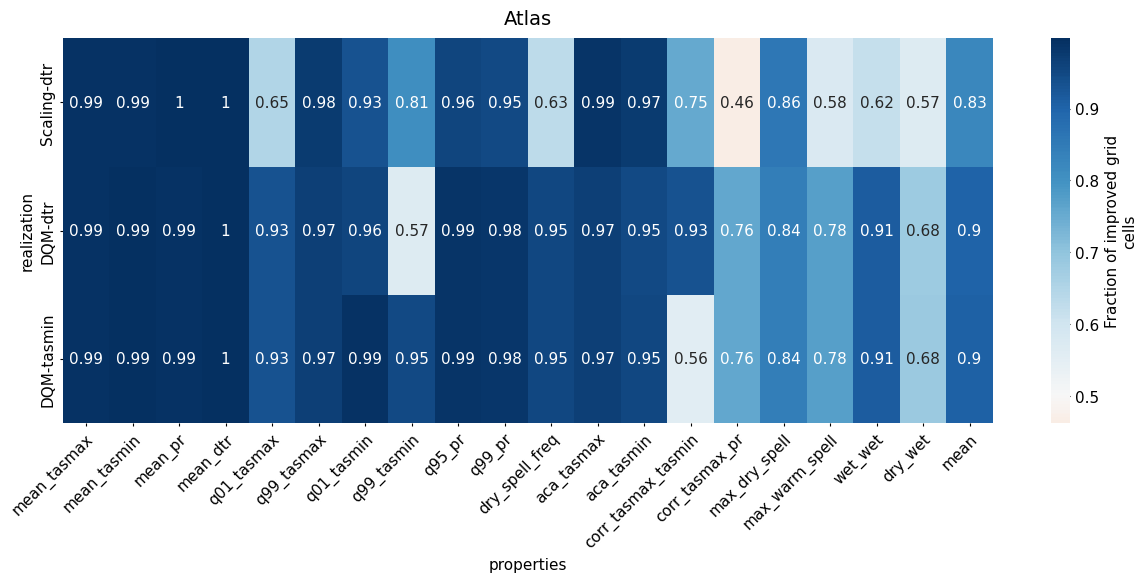

In [9]:

for r in ['Atlas']:

    imps=[]
    means=[]
    for m in [ 'Scaling','DQM', 'tasmin']:
        im=[]
        for f in np.sort(glob.glob(f"{CONFIG[m]}/diagnostics/CaSR/NAM/{r}/CMIP6*/*imp.zarr.zip")):
            imp=xr.open_zarr(f, decode_timedelta=False)
            imp=imp.expand_dims(realization=[f"{m}_{imp.attrs['cat:id']}"])
            imp=imp.drop_vars('crs', errors='ignore')
            imps.append(imp)
            im.append(imp)
        ds_m= xr.concat(im, dim='realization')
        means.append(ds_m.mean(dim='realization').expand_dims(realization=[f"{m}_mean"]))

    ds_imp= xr.concat(imps+means, dim='realization')
    ds_imp=ds_imp.sel(properties=["mean_tasmax","mean_tasmin","mean_pr","mean_dtr","q01_tasmax","q99_tasmax","q01_tasmin","q99_tasmin","q95_pr","q99_pr","dry_spell_freq","aca_tasmax","aca_tasmin","corr_tasmax_tasmin","corr_tasmax_pr","max_dry_spell","max_warm_spell","wet_wet","dry_wet",])
    ds_imp=ds_imp.drop_vars(['rotated_pole', 'crs','quantization_info'], errors='ignore')

    mean_row = ds_imp.mean(dim="properties")

    # 3. Add a new coordinate name to the mean data
    mean_row = mean_row.expand_dims(properties=["mean"])
    
    # 4. Concatenate the original data with the new mean row
    ds_imp = xr.concat([ds_imp, mean_row], dim="properties")
    
    ax=fg.heatmap(ds_imp,plot_kw={'annot':True, }, fig_kw={'figsize':(15,5)}, divergent=0.5)
    ax.set_title(r)

    # for report change name
    out=ds_imp.sel(realization=['Scaling_mean', 'DQM_mean', 'tasmin_mean'])
    out['realization']=['Scaling-dtr', 'DQM-dtr', 'DQM-tasmin']
    ax=fg.heatmap(out,plot_kw={'annot':True, }, fig_kw={'figsize':(15,5)}, divergent=0.5)
    ax.set_title(r)
    plt.savefig(f"{CONFIG['figures']}/value.pdf",bbox_inches='tight')

# Count inversion tasmin tasmax

In [26]:
for sim_id in ids:
    print(sim_id)
    count_flip=[]
    count_total=[]
    for i in range(6):
        ds_tasmax= xr.open_zarr(f"{CONFIG['regTasmin']}/{sim_id}+NAM+CaSR+sr-{i}+tasmax+adjusted.zarr")
        ds_tasmin= xr.open_zarr(f"{CONFIG['regTasmin']}/{sim_id}+NAM+CaSR+sr-{i}+tasmin+adjusted.zarr")
        t=ds_tasmin.tasmin.count().values
        print(t)
        count_total.append(t)
        inversion= ds_tasmin.tasmin>ds_tasmax.tasmax
        # df = inversion.to_dataframe(name='inversion').reset_index()
        # df = df[df.inversion]
        # c=len(df)
        c= inversion.sum().values
        print(c)
        count_flip.append(c)
    print('total of of point')
    print(np.sum(count_total))
    print('total of flip')
    print(np.sum(count_flip))
    print('ratio')
    print(np.sum(count_flip)/np.sum(count_total))

CMIP6_CORDEX_MPI-ESM1-2-LR_r1i1p1f1_OURANOS_CRCM5-SN_ssp370_r1_NAM-12
2755750000
2214683
2755750000
3375522
2755750000
13893582
2755750000
32355702
2755750000
49061704
1493285810
25687318
total of of point
15272035810
total of flip
126588511
ratio
0.00828890873324897
CMIP6_CORDEX_CanESM5_r1i1p2f1_OURANOS_CRCM5-SN_ssp370_r1_NAM-12
2755750000
2046432
2755750000
3703162
2755750000
15540567
2755750000
43107925
2755750000
61662005
1493285810
38692454
total of of point
15272035810
total of flip
164752545
ratio
0.010787857431038855
CMIP6_CORDEX_NorESM2-MM_r1i1p1f1_OURANOS_CRCM5-SN_ssp370_r1_NAM-12
2755750000
3433385
2755750000
4994223
2755750000
15023038
2755750000
25449609
2755750000
42101307
1493285810
24960882
total of of point
15272035810
total of flip
115962444
ratio
0.0075931228450936954


In [32]:
(126588511+164752545+115962444)/(15272035810*3)

0.008889963003127173

# Proche de zero

/lustre06/project/6046550/scenario/environnements/envs/xscen-0.14/lib/python3.12/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "long_name" not found.
/lustre06/project/6046550/scenario/environnements/envs/xscen-0.14/lib/python3.12/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "long_name" not found.
/lustre06/project/6046550/scenario/environnements/envs/xscen-0.14/lib/python3.12/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "long_name" not found.
/lustre06/project/6046550/scenario/environnements/envs/xscen-0.14/lib/python3.12/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "long_name" not found.
/lustre06/project/6046550/scenario/environnements/envs/xscen-0.14/lib/python3.12/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "long_name" not found.
/lustre06/project/6046550/scenario/environnements/envs/xscen-0.14/lib/python3.12/site-packages/figanos/matplotlib/utils.py:222: Us

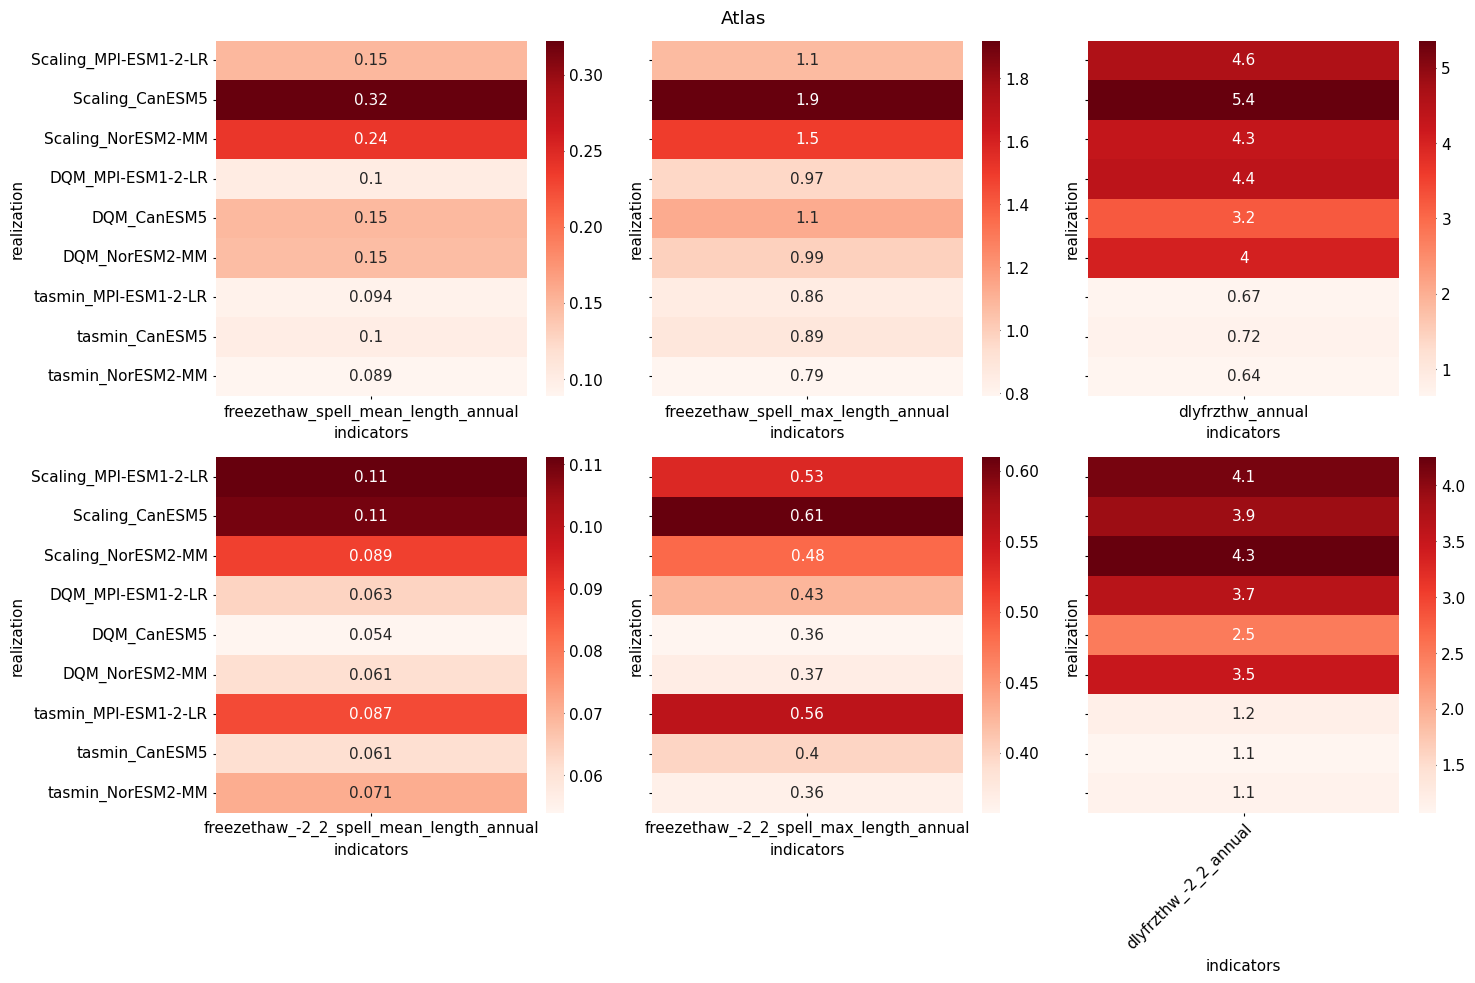

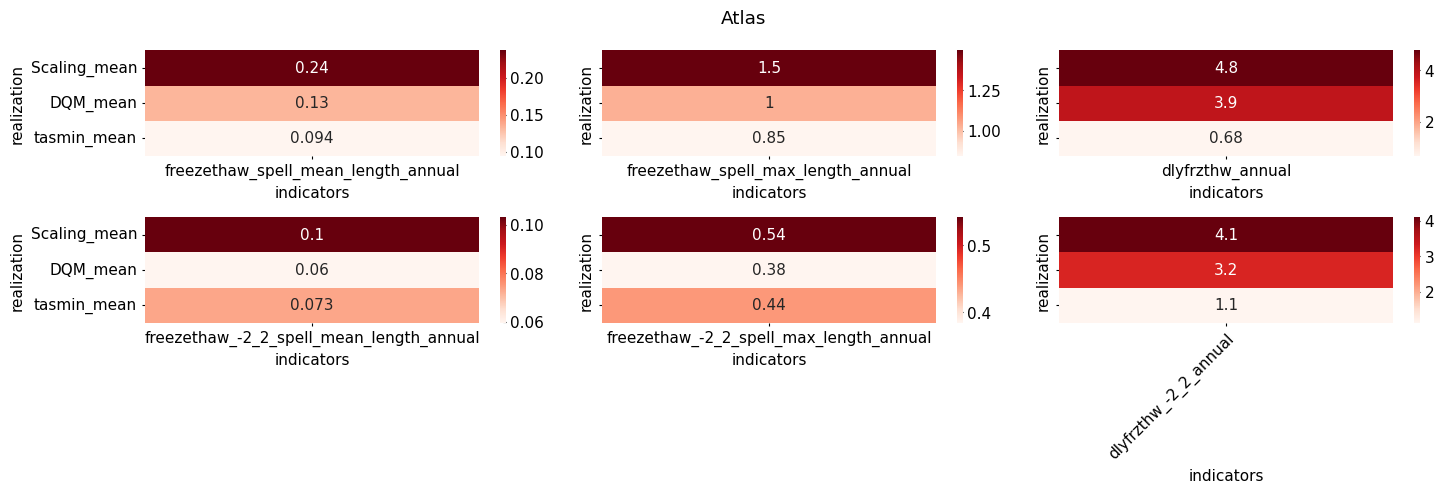

In [12]:
def _rmse(sim, ref):
    return np.sqrt(np.nanmean((sim - ref) ** 2, axis=-1))
inds=['freezethaw_spell_mean_length_annual','freezethaw_spell_max_length_annual',
      'dlyfrzthw_annual',#'solidprcptot_annual',
     'freezethaw_-2_2_spell_mean_length_annual','freezethaw_-2_2_spell_max_length_annual',
      'dlyfrzthw_-2_2_annual',#'heat_spell_total_length_class1'
     ]
v2=[]
v2qc=[]
for var in inds:
    ds_ref= xr.open_zarr(f"{CONFIG['pathind']}/CaSR_{var}.zarr.zip", decode_timedelta=False)
    ds_ref_clim= ds_ref.sel(time=slice('1991','2020')).mean('time')

    ds_ref_clim_qc=xs.spatial.subset(ds_ref_clim, method='bbox',
                                                 lon_bnds= [-83 ,-55 ] ,lat_bnds= [42, 53])

    v=[]
    vqc=[]
    real=[]
    for m in [ 'Scaling','DQM', 'tasmin']:
        for dm in ['MPI-ESM1-2-LR','CanESM5','NorESM2-MM']:
            #print(f"{var} {m}_{dm}")

            ds_sim = xr.open_zarr(f"{CONFIG['pathind']}/{m}_{dm}_{var}.zarr.zip", decode_timedelta=False)
            ds_sim_clim= ds_sim.sel(time=slice('1991','2020')).mean('time')

            #NAM
            rmse_sim = xr.apply_ufunc(
                _rmse,
                ds_sim_clim[var].stack(loc=['rlat','rlon']).chunk(dict(loc=-1)),
                ds_ref_clim[var].stack(loc=['rlat','rlon']).chunk(dict(loc=-1)),
                input_core_dims=[["loc"], ["loc"]],
                dask="parallelized",
            ).values
            v.append(rmse_sim)

            # QC
            ds_sim_clim_qc=xs.spatial.subset(ds_sim_clim, method='bbox',
                                                 lon_bnds= [-83 ,-55 ] ,lat_bnds= [42, 53])

            rmse_sim_qc = xr.apply_ufunc(
                _rmse,
                ds_sim_clim_qc[var].stack(loc=['rlat','rlon']).chunk(dict(loc=-1)),
                ds_ref_clim_qc[var].stack(loc=['rlat','rlon']).chunk(dict(loc=-1)),
                input_core_dims=[["loc"], ["loc"]],
                dask="parallelized",
            ).values
            vqc.append(rmse_sim_qc)
            
            
            real.append(f"{m}_{dm}")
    v2.append(v)
    v2qc.append(vqc)

# #NAM
# v2=np.array(v2).T
# ds= xr.DataArray(v2, dims=['realization','indicators'], coords={'realization':real, 'indicators':inds})
# ds

# fig, axs= plt.subplots(2,3, figsize=(15,10), sharey=True)
# fig.suptitle('NAM')
# axs=np.ravel(axs)
# for i,p in enumerate(inds):
#     ds_ref= xr.open_zarr(f"{CONFIG['pathind']}/CaSR_{var}.zarr.zip", decode_timedelta=False)
#     ds.attrs['units']=ds_ref[var].attrs['units']
#     fg.heatmap(ds.sel(indicators=[p]),plot_kw={'annot':True,  }, ax=axs[i], cmap='Reds')
# plt.tight_layout()

#QC
v2qc=np.array(v2qc).T
dsqc= xr.DataArray(v2qc, dims=['realization','indicators'], coords={'realization':real, 'indicators':inds})

fig, axs= plt.subplots(2,3, figsize=(15,10), sharey=True)
fig.suptitle('Atlas')
axs=np.ravel(axs)
for i,p in enumerate(inds):
    ds_ref= xr.open_zarr(f"{CONFIG['pathind']}/CaSR_{var}.zarr.zip", decode_timedelta=False)
    dsqc.attrs['units']=ds_ref[var].attrs['units']
    fg.heatmap(dsqc.sel(indicators=[p]),plot_kw={'annot':True,  }, ax=axs[i], cmap='Reds')
plt.tight_layout()


# mean=[]
# for m in ['DQM', 'Scaling', 'tasmin']:
#     cur=ds.sel(realization=[f"{m}_{x.split('_')[2]}" for x in ids]).mean('realization')
#     cur=cur.expand_dims(realization=[f"{m}_mean"])
#     mean.append(cur)
# ds_mean=xr.concat(mean, dim='realization')

# fig, axs= plt.subplots(2,3, figsize=(15,5), sharey=True)
# fig.suptitle('NAM')
# axs=np.ravel(axs)
# for i,p in enumerate(inds):
#     ds.attrs['units']=ds_ref[var].attrs['units']
#     fg.heatmap(ds_mean.sel(indicators=[p]),plot_kw={'annot':True,  }, ax=axs[i], cmap='Reds')
# plt.tight_layout()


mean=[]
for m in [ 'Scaling','DQM', 'tasmin']:
    cur=dsqc.sel(realization=[f"{m}_{x.split('_')[2]}" for x in ids]).mean('realization')
    cur=cur.expand_dims(realization=[f"{m}_mean"])
    mean.append(cur)
ds_mean=xr.concat(mean, dim='realization')

fig, axs= plt.subplots(2,3, figsize=(15,5), sharey=True)
fig.suptitle('Atlas')
axs=np.ravel(axs)
for i,p in enumerate(inds):
    dsqc.attrs['units']=ds_ref[var].attrs['units']
    fg.heatmap(ds_mean.sel(indicators=[p]),plot_kw={'annot':True,  }, ax=axs[i], cmap='Reds')
plt.tight_layout()
